In [1]:
from langgraph.graph import StateGraph,START,END
import os
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from dotenv import load_dotenv
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import TypedDict,List
from langchain_community.vectorstores import FAISS
from pydantic import BaseModel
from langchain_openai import ChatOpenAI,OpenAIEmbeddings


c:\Coding\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
llm = ChatOpenAI(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
)

In [6]:
docs=(
    PyPDFLoader("../Document/book1.pdf").load()+
    PyPDFLoader("../Document/book2.pdf").load()+
    PyPDFLoader("../Document/book3.pdf").load()
)

In [23]:
print(len(docs))

2123


In [7]:
splitters=RecursiveCharacterTextSplitter(chunk_size=900,chunk_overlap=150)

chunks=splitters.split_documents(docs)

In [8]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1"
)

In [9]:
vectorstore=FAISS.from_documents(chunks,embeddings)

In [10]:
retriever=vectorstore.as_retriever(search_type='similarity',search_kwargs={'k':4})

In [11]:
# class state(TypedDict):
#     que:str
#     docs:List[Document]

#     strips:List[str]
#     kept_strips:List[str]
#     refined_contex:str

#     answer:str

class State(TypedDict):
    que: str
    docs: List[Document]

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    answer: str

In [12]:
def retrieve(state:State)->State:
    q=state['que']
    return{
        "docs":retriever.invoke(q)
    }

In [13]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------

def decompose_to_sentence(text:str)->List[str]:
    text=re.sub(r"\s+"," ",text).strip()
    sentence=re.split(r"(?<=[.!?])\s+",text)
    return [s.strip() for s in sentence if len(s.strip())>20]

# -----------------------------
# FILTER (LLM judge)
# -----------------------------

class KeepOrDrop(BaseModel):
    keep:bool

filter_prompt=ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        (
            "human", "Question: {question}\n\nSentence:\n{sentence}"
        )
    ]
)

filter_chain=filter_prompt|llm.with_structured_output(KeepOrDrop)

In [14]:
def refine(state:State)->State:
    q=state['que']

    context="\n\n".join(d.page_content for d in state["docs"]).strip()

    strips=decompose_to_sentence(context)

    kept:List[str]=[]

    for s in strips:
        if filter_chain.invoke({"question":q,"sentence":s}).keep:
            kept.append(s)
    
    redefined_context="\n".join(kept).strip()

    return{
        "strips":strips,
        "kept_strips":kept,
        "refined_context":redefined_context,
    }

In [15]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state:State)->State:
    out=(answer_prompt|llm).invoke({"question": state["que"], "refined_context": state['refined_context']})
    return {"answer": out.content}

In [16]:
graph=StateGraph(State)

graph.add_node("Retrive",retrieve)
graph.add_node("Refine",refine)
graph.add_node("Generate",generate)

graph.add_edge(START,"Retrive")
graph.add_edge("Retrive","Refine")
graph.add_edge("Refine","Generate")
graph.add_edge("Generate",END)

In [17]:
app=graph.compile()

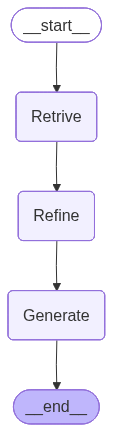

In [18]:
app

In [19]:
res=app.invoke({
    "que":"Explain The bias-variance tradeoff",
    "docs":[],
    "strips":[],
    "kept_strips":[],
    "refined_context":"",
    "answer":""
})

In [20]:
print(res["answer"])

The bias‑variance tradeoff describes how a model’s expected generalization error can be split into three components:  

- **Bias** – error arising from incorrect assumptions about the underlying data‑generating process (e.g., assuming linearity when the true relationship is quadratic). A high‑bias model tends to under‑fit the training data.  
- **Variance** – error due to the model’s excessive sensitivity to small fluctuations in the training set; it captures how much the model’s predictions change when trained on different samples.  
- **Irreducible noise** – a constant term that cannot be reduced by any model.

Mathematically, the expected loss equals (squared bias) + variance + noise.  

Because bias and variance move in opposite directions as model flexibility changes, there is a tradeoff:  

- **Very flexible models** (e.g., high‑degree polynomials, deep networks) can fit the training data closely, giving low bias but they also react strongly to noise in the training set, leading 

In [21]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

10 This notion of bias is not to be confused with the bias term of linear models.
Figure 4-16. Learning curves for the polynomial model
One way to improve an overfitting model is to feed it more training
da
ta until the validation error reaches the training error.
The Bias/Variance Tradeoff
An importan
t theoretical result of statistics and Machine Learning is the fact that a
model’s generaliza
tion error can be expressed as the sum of three very different
errors:
Bias
This part of the generalization error is due to wrong assumptions, such as assum‐
ing that the data is linear when it is actually quadratic. A high-bias model is most
likely to underfit the training data.10
Variance
This part is due to the model’s excessive sensitivity to small variations in the
training data. A model with many degrees of freedom (such as a high-degree pol‐
****************************************************************************************************
and the bias and variance terms now refer to int

In [22]:
print(res['refined_context'])

The Bias/Variance Tradeoff An importan t theoretical result of statistics and Machine Learning is the fact that a model’s generaliza tion error can be expressed as the sum of three very different errors: Bias This part of the generalization error is due to wrong assumptions, such as assum‐ ing that the data is linear when it is actually quadratic.
A high-bias model is most likely to underfit the training data.10 Variance This part is due to the model’s excessive sensitivity to small variations in the training data.
Our goal is to minimize the expected loss, which we have decomposed into the sum of a (squared) bias, a variance, and a constant noise term.
As we shall see, there is a trade-off between bias and variance, with very ﬂexible models having low bias and high variance, and relatively rigid models having high bias and low variance.
The model with the optimal predictive capability is the one that leads to the best balance between bias and variance.
The average prediction is estima